In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score

In [18]:
X = np.load("../processed/X_no_norm.npy")
y = np.load("../processed/y_no_norm.npy")
subjects = np.load("../processed/subjects_no_norm.npy")

print(X.shape)
print(y.shape)
print(subjects.shape)

(4635, 7, 297)
(4635,)
(4635,)


In [19]:
X_flat = X.reshape(
    X.shape[0],
    -1
)

print(X_flat.shape)

(4635, 2079)


In [20]:
gkf = GroupKFold(n_splits=10)

train_idx, test_idx = next(
    gkf.split(
        X_flat,
        y,
        subjects
    )
)

X_train = X_flat[train_idx]
X_test = X_flat[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

print(X_train.shape)
print(X_test.shape)

(4140, 2079)
(495, 2079)


In [21]:
rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1

)

rf.fit(
    X_train,
    y_train
)

pred = rf.predict(X_test)

acc = accuracy_score(
    y_test,
    pred
)

print("Accuracy:", acc)

Accuracy: 0.7676767676767676


In [22]:
importance = rf.feature_importances_

print(importance.shape)

(2079,)


In [23]:
indices = np.argsort(
    importance
)[::-1]

top20 = indices[:20]

print(top20)

[ 429  407  473  440  297  495  484  418  451  308  330 1320  396 1298
  341  506 1023  462 1364  770]


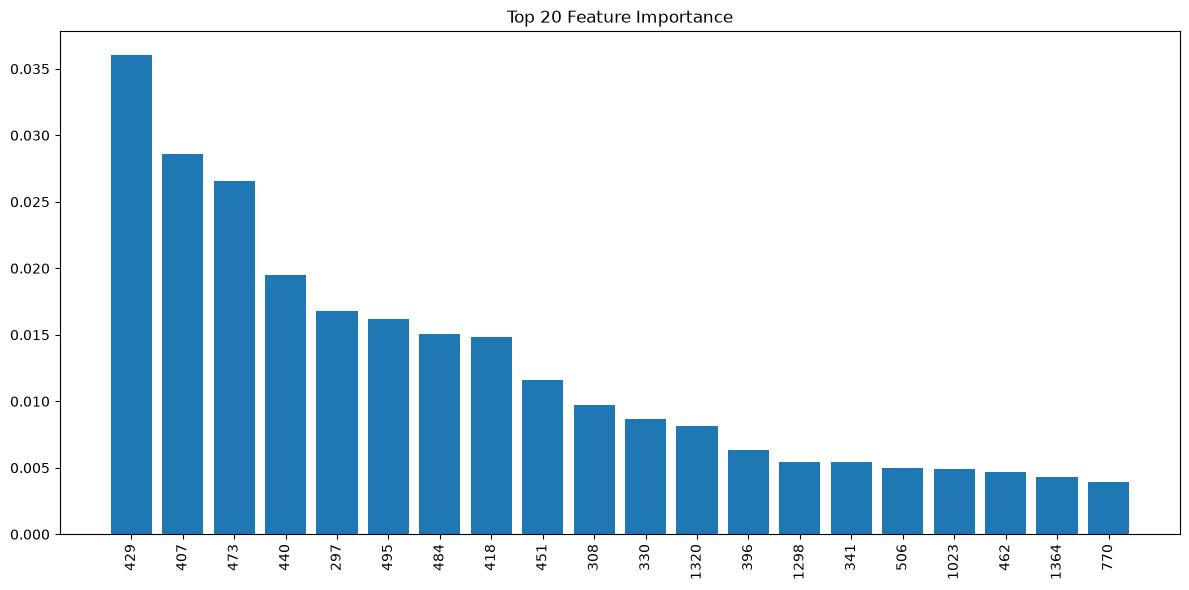

In [24]:
plt.figure(figsize=(12,6))

plt.bar(
    range(20),
    importance[top20]
)

plt.xticks(
    range(20),
    top20,
    rotation=90
)

plt.title("Top 20 Feature Importance")

plt.tight_layout()

plt.show()

In [25]:
feature_names = [

    "Mean",
    "Variance",
    "Skewness",
    "Kurtosis",
    "ZeroCross",
    "Area",
    "Range",
    "Delta",
    "Theta",
    "Alpha",
    "Beta"

]

channel_names = [

'FC5-FC6',
'FC3-FC4',
'FC1-FC2',

'C5-C6',
'C3-C4',
'C1-C2',

'CP5-CP6',
'CP3-CP4',
'CP1-CP2',

'FP1-FP2',

'AF7-AF8',
'AF3-AF4',

'F7-F8',
'F5-F6',
'F3-F4',
'F1-F2',

'FT7-FT8',

'T7-T8',
'T9-T10',

'TP7-TP8',

'P7-P8',
'P5-P6',
'P3-P4',
'P1-P2',

'PO7-PO8',
'PO3-PO4',

'O1-O2'

]

rows = []

for idx, imp in enumerate(importance):

    window = idx // 297

    inside_window = idx % 297

    channel = inside_window // 11

    feature = inside_window % 11

    rows.append([

        idx,

        window,

        channel_names[channel],

        feature_names[feature],

        imp

    ])

df = pd.DataFrame(

    rows,

    columns=[

        "FeatureID",

        "Window",

        "Channel",

        "Feature",

        "Importance"

    ]

)

df.head()

,FeatureID,Window,Channel,Feature,Importance
0,0,0,FC5-FC6,Mean,0.000922
1,1,0,FC5-FC6,Variance,0.000000
2,2,0,FC5-FC6,Skewness,0.001057
3,3,0,FC5-FC6,Kurtosis,0.000733
4,4,0,FC5-FC6,ZeroCross,0.000507


Feature
Mean         0.427803
Skewness     0.147636
Kurtosis     0.130991
Area         0.102745
Range        0.096403
ZeroCross    0.094351
Variance     0.000072
Beta         0.000000
Alpha        0.000000
Delta        0.000000
Theta        0.000000
Name: Importance, dtype: float64


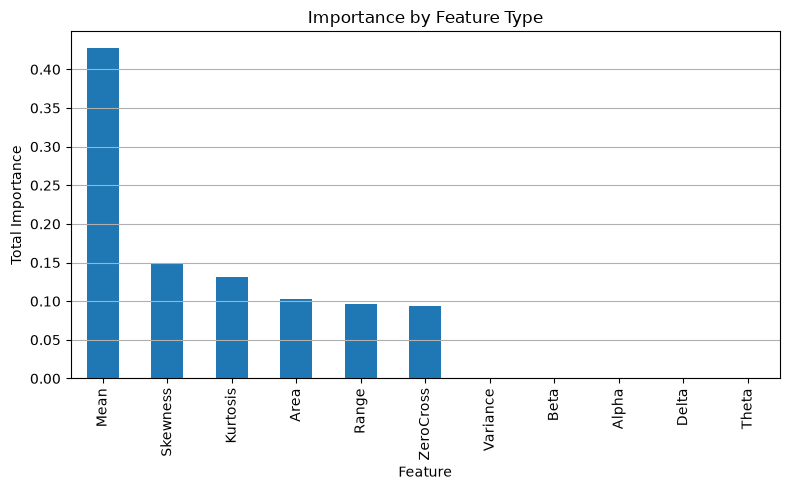

In [26]:
feature_summary = (

    df

    .groupby("Feature")["Importance"]

    .sum()

    .sort_values(ascending=False)

)

print(feature_summary)

plt.figure(figsize=(8,5))

feature_summary.plot(kind="bar")

plt.ylabel("Total Importance")

plt.title("Importance by Feature Type")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

Channel
F7-F8      0.087955
AF7-AF8    0.070284
FT7-FT8    0.067380
F5-F6      0.051761
T9-T10     0.048804
AF3-AF4    0.045417
FC5-FC6    0.045207
T7-T8      0.043299
F3-F4      0.038370
C5-C6      0.034513
FC3-FC4    0.033626
FP1-FP2    0.031489
C3-C4      0.030966
TP7-TP8    0.029015
CP5-CP6    0.028919
F1-F2      0.028260
FC1-FC2    0.028021
P5-P6      0.027047
C1-C2      0.026527
P7-P8      0.026261
O1-O2      0.026199
PO7-PO8    0.025866
CP3-CP4    0.025849
CP1-CP2    0.025256
PO3-PO4    0.025074
P1-P2      0.024394
P3-P4      0.024240
Name: Importance, dtype: float64


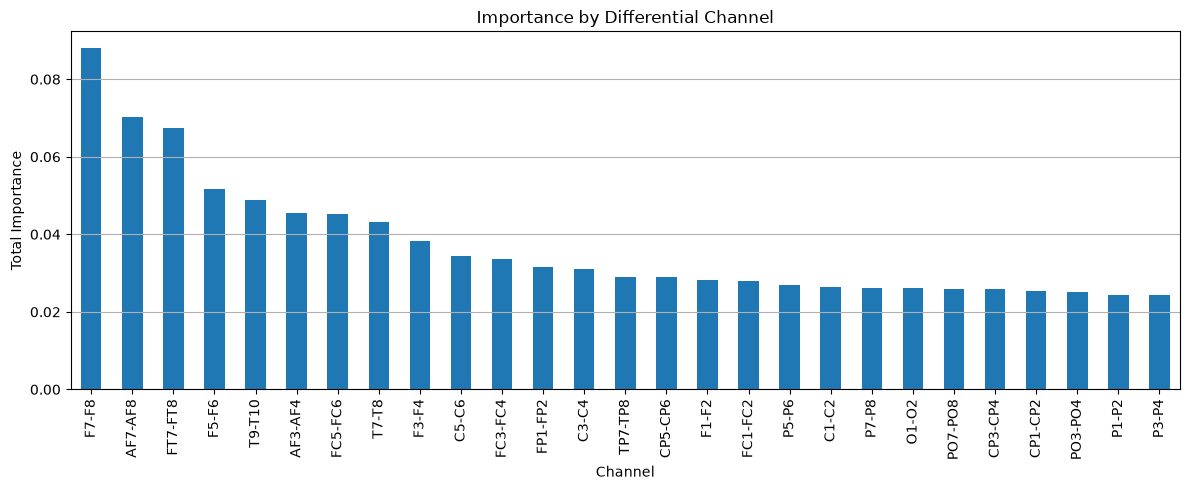

In [27]:
channel_summary = (

    df

    .groupby("Channel")["Importance"]

    .sum()

    .sort_values(ascending=False)

)

print(channel_summary)

plt.figure(figsize=(12,5))

channel_summary.plot(kind="bar")

plt.ylabel("Total Importance")

plt.title("Importance by Differential Channel")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [28]:
top30 = (

    df

    .sort_values(

        "Importance",

        ascending=False

    )

    .head(30)

)

top30

,FeatureID,Window,Channel,Feature,Importance
429,429,1,F7-F8,Mean,0.036040
407,407,1,AF7-AF8,Mean,0.028624
473,473,1,FT7-FT8,Mean,0.026570
440,440,1,F5-F6,Mean,0.019515
297,297,1,FC5-FC6,Mean,0.016793
495,495,1,T9-T10,Mean,0.016167
484,484,1,T7-T8,Mean,0.015057
418,418,1,AF3-AF4,Mean,0.014857
451,451,1,F3-F4,Mean,0.011607
308,308,1,FC3-FC4,Mean,0.009701


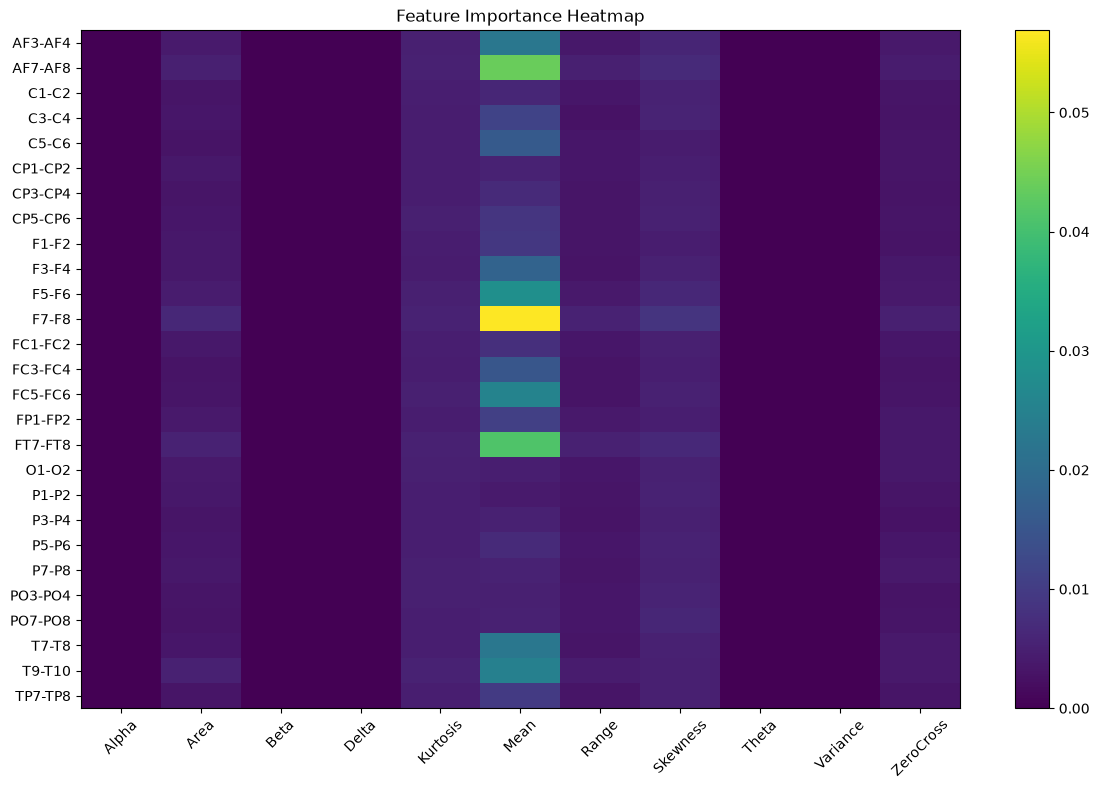

In [29]:
heatmap = (

    df

    .groupby(

        ["Channel","Feature"]

    )["Importance"]

    .sum()

    .unstack()

)

plt.figure(figsize=(12,8))

plt.imshow(

    heatmap,

    aspect="auto"

)

plt.colorbar()

plt.xticks(

    range(len(heatmap.columns)),

    heatmap.columns,

    rotation=45

)

plt.yticks(

    range(len(heatmap.index)),

    heatmap.index

)

plt.title("Feature Importance Heatmap")

plt.tight_layout()

plt.show()

In [30]:
print("\nTop 10 Channels\n")

print(

    channel_summary.head(10)

)


Top 10 Channels

Channel
F7-F8      0.087955
AF7-AF8    0.070284
FT7-FT8    0.067380
F5-F6      0.051761
T9-T10     0.048804
AF3-AF4    0.045417
FC5-FC6    0.045207
T7-T8      0.043299
F3-F4      0.038370
C5-C6      0.034513
Name: Importance, dtype: float64


In [31]:
print("\nTop Feature Types\n")

print(

    feature_summary

)


Top Feature Types

Feature
Mean         0.427803
Skewness     0.147636
Kurtosis     0.130991
Area         0.102745
Range        0.096403
ZeroCross    0.094351
Variance     0.000072
Beta         0.000000
Alpha        0.000000
Delta        0.000000
Theta        0.000000
Name: Importance, dtype: float64


Window
0    0.123012
1    0.325874
2    0.122137
3    0.105532
4    0.121147
5    0.104476
6    0.097822
Name: Importance, dtype: float64


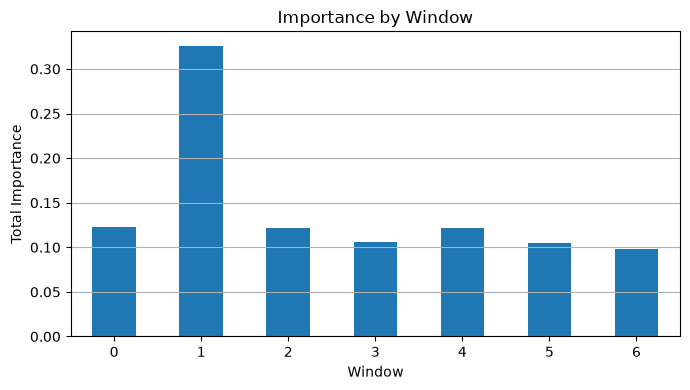

In [33]:
window_summary = (

    df

    .groupby("Window")["Importance"]

    .sum()

    .sort_index()

)

print(window_summary)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

window_summary.plot(kind="bar")

plt.ylabel("Total Importance")

plt.title("Importance by Window")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [34]:
print("\nWindow Importance\n")

print(

    window_summary

)


Window Importance

Window
0    0.123012
1    0.325874
2    0.122137
3    0.105532
4    0.121147
5    0.104476
6    0.097822
Name: Importance, dtype: float64
